# Olist Marketplace Analytics

A decision-maker's view of the Olist Brazilian e-commerce dataset, rendered
inline. All analysis lives in the `olist_analytics` package — this notebook
just calls into it section by section. See `README.md` for project overview
and design choices.

The five sections move from broad to specific:

1. **Marketplace overview** — headline KPIs, lifecycle funnel, completion trend
2. **Geographic performance** — where the platform is strong, where under-developed
3. **Seller performance & lifecycle** — quality, concentration, cohort survival
4. **Payment mix & non-completion** — installments, payment types, cancellation drivers
5. **Product categories & customer experience** — revenue share, repeat behavior, review drivers


## Setup

In [1]:
import os
print(os.getcwd())

c:\Users\user\Downloads\repo\notebooks


In [ ]:
wd = r'c:\Users\user\Downloads\repo'
os.chdir(r'c:\Users\user\Downloads\repo')

In [3]:
from olist_analytics.config import Config
from olist_analytics.loaders import load_all
from olist_analytics.style import apply_style

apply_style()
config = Config.from_yaml(wd+"/configs/default.yaml")
data = load_all(config.data_dir)

print(f"Loaded {len(data.orders):,} orders, "
      f"{data.sellers['seller_id'].nunique():,} sellers, "
      f"{data.customers['customer_unique_id'].nunique():,} unique customers")
print(f"Date range: {data.orders['order_purchase_timestamp'].min()} → "
      f"{data.orders['order_purchase_timestamp'].max()}")


Loaded 99,441 orders, 3,095 sellers, 96,096 unique customers
Date range: 2016-09-04 21:15:19 → 2018-10-17 17:30:18


---
# 1. Marketplace overview

### 1.1 Headline KPIs

**📖 Definitions**

- **GMV (Gross Merchandise Value):** total monetary value of items sold. Excludes freight (pass-through to carriers).
- **AOV (Average Order Value):** mean payment value per order.
- **Repeat-buyer rate:** % of unique customers with more than one order. Snapshot loyalty metric — biased downward for late-acquired buyers.
- **Merchant churn:** % of sellers inactive for ≥ 90 days (configurable).
- **Negative-review %:** share of reviews scoring 1★ or 2★.


In [4]:
from olist_analytics.analyses.section1_overview import compute_headline_kpis

kpis = compute_headline_kpis(data, config)
print(f"GMV: R$ {kpis.gmv:,.0f}")
print(f"AOV: R$ {kpis.aov:,.2f}")
print(f"Repeat rate:        {kpis.repeat_rate_pct:.2f}%")
print(f"Merchant churn:     {kpis.merchant_churn_pct:.2f}%")
print(f"Negative reviews:   {kpis.negative_review_pct:.2f}%")


GMV: R$ 13,591,644
AOV: R$ 160.99
Repeat rate:        3.12%
Merchant churn:     51.60%
Negative reviews:   14.69%


### 1.2 Marketplace dashboard

Four-panel view: monthly GMV, active-seller growth, review distribution, and
repeat-vs-one-time customer split. The repeat share is small (~3%) — Olist is
structurally low-frequency. Treat retention as a category characteristic, not
a KPI to optimize.


C:\Users\user\AppData\Local\Temp\ipykernel_12884\1281691779.py:4: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


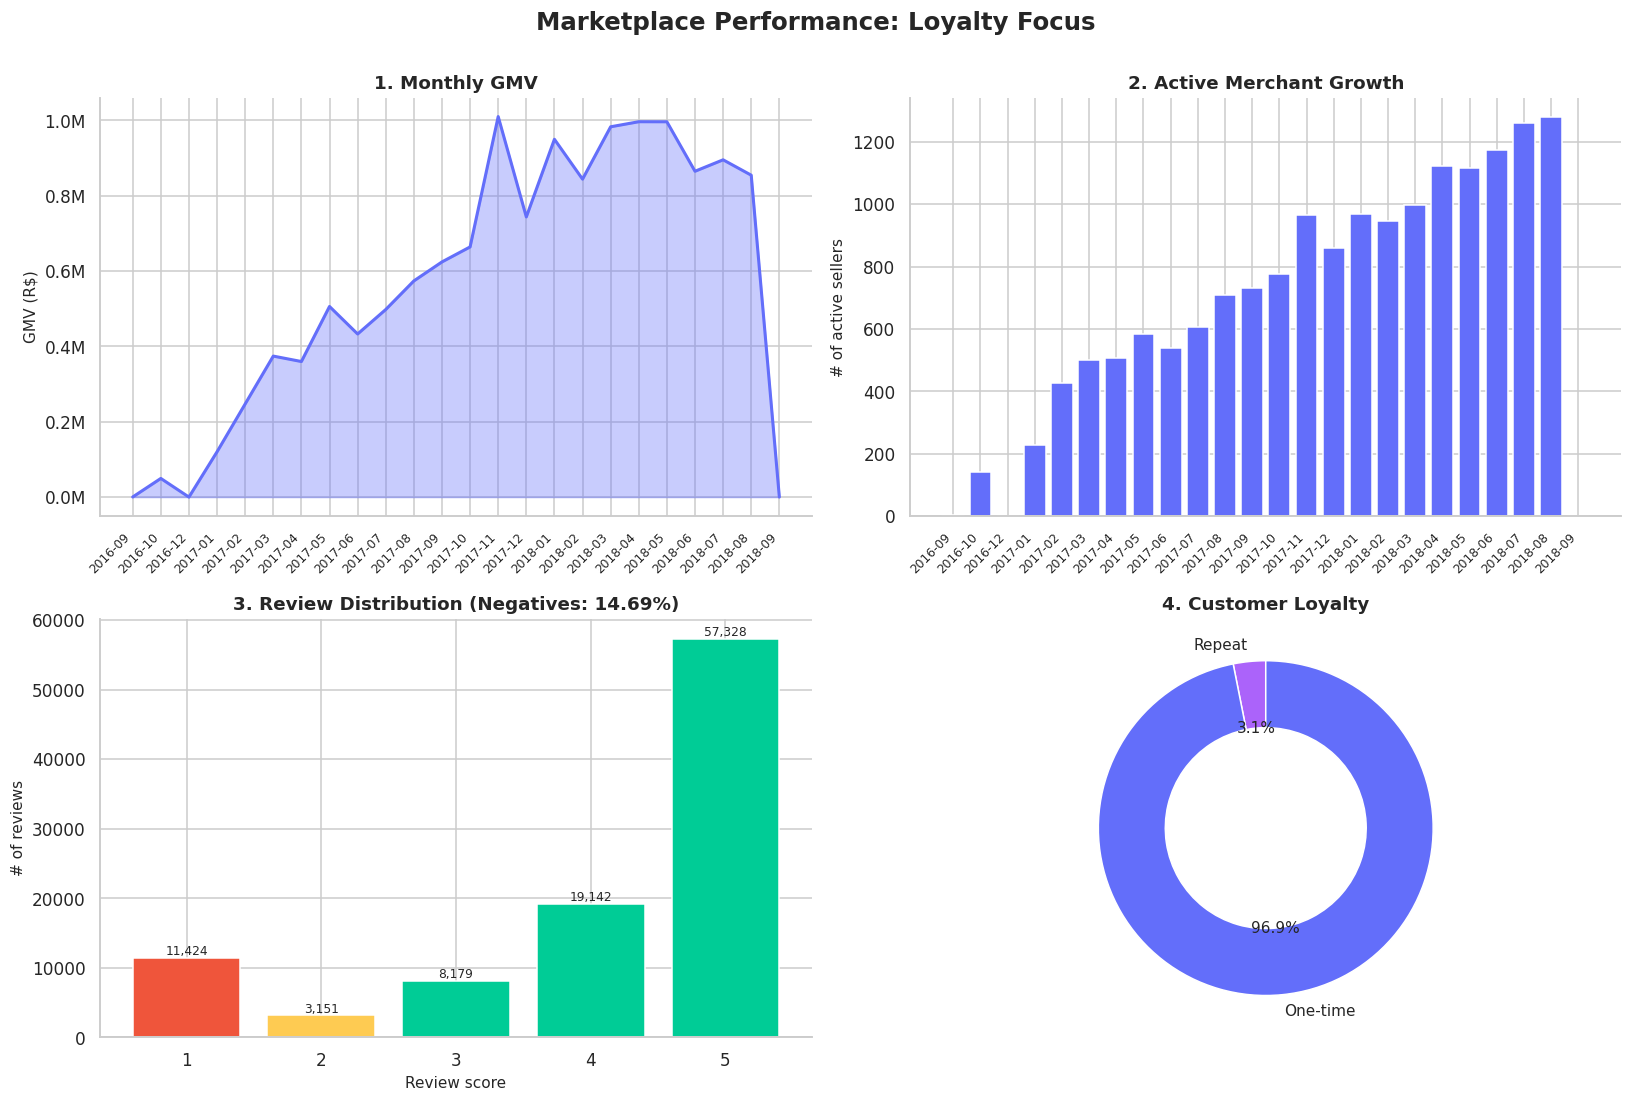

In [5]:
from olist_analytics.analyses.section1_overview import plot_marketplace_dashboard

fig = plot_marketplace_dashboard(data)
fig.show()


### 1.3 Order lifecycle funnel

Drop-off across the lifecycle is small (~3pp), so a chart would just be four
near-equal bars; the numbers are presented as text instead.


In [6]:
from olist_analytics.analyses.section1_overview import order_lifecycle_funnel

funnel = order_lifecycle_funnel(data)
print("Order lifecycle funnel")
print("-" * 42)
for stage, (count, pct) in funnel.items():
    print(f"  {stage:9s}  {count:>7,}  ({pct:5.1f}%)")


Order lifecycle funnel
------------------------------------------
  Placed      99,441  (100.0%)
  Approved    99,281  ( 99.8%)
  Shipped     97,658  ( 98.2%)
  Delivered   96,476  ( 97.0%)


### 1.4 Non-completed orders over time

Tracks % of orders ending `canceled` or `unavailable` per month. Edge months
with very few orders are excluded — tiny denominators produce misleading spikes.


C:\Users\user\AppData\Local\Temp\ipykernel_12884\111836241.py:4: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


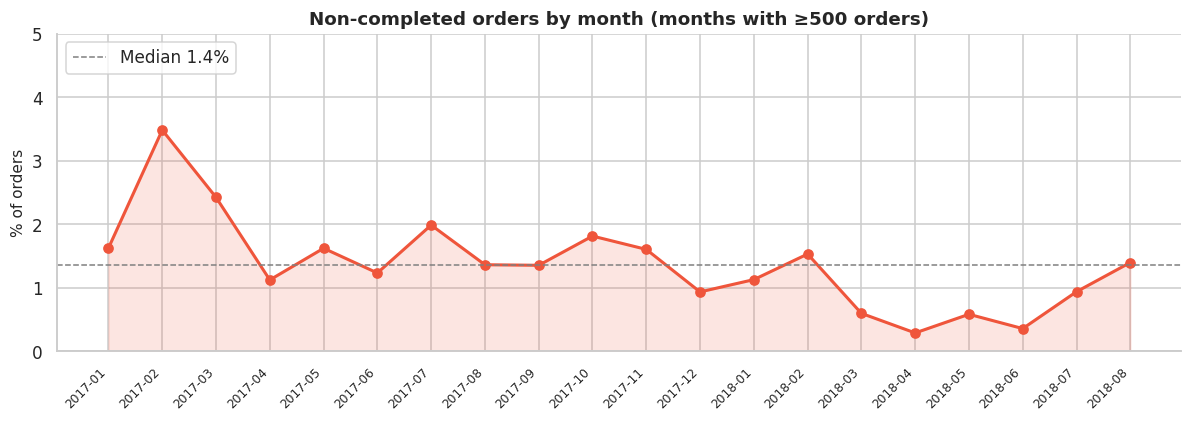

In [7]:
from olist_analytics.analyses.section1_overview import plot_non_completion_trend

fig = plot_non_completion_trend(data, config)
fig.show()


---
# 2. Geographic performance

### 2.1 Per-state KPI table

Builds a dataframe of GMV, buyers, sellers, freight, and per-capita metrics
per state. IBGE 2018 population estimates supply the per-capita denominator.


In [8]:
from olist_analytics.analyses.section2_geography import build_state_table

state_table = build_state_table(data, config)
state_table.head(10).round(1)


,gmv,freight,orders,buyers,freight_pct_of_price,gmv_per_buyer,sellers,population_m,gmv_per_capita,buyers_per_1k,sellers_per_1k
customer_state,,,,,,,,,,,
SP,5202955.0,718723.1,41375,41375,13.8,125.8,1849.0,45.5,114350.7,0.9,0.0
RJ,1824092.7,305589.3,12762,12762,16.8,142.9,171.0,17.2,106051.9,0.7,0.0
MG,1585308.0,270853.5,11544,11544,17.1,137.3,244.0,21.0,75490.9,0.5,0.0
RS,750304.0,135522.7,5432,5432,18.1,138.1,129.0,11.3,66398.6,0.5,0.0
PR,683083.8,117851.7,4998,4998,17.3,136.7,349.0,11.4,59919.6,0.4,0.0
SC,520553.3,89660.3,3612,3612,17.2,144.1,190.0,7.1,73317.4,0.5,0.0
BA,511350.0,100156.7,3358,3358,19.6,152.3,19.0,14.8,34550.7,0.2,0.0
DF,302603.9,50625.5,2125,2125,16.7,142.4,30.0,3.0,100868.0,0.7,0.0
GO,294592.0,53115.0,2007,2007,18.0,146.8,40.0,7.0,42084.6,0.3,0.0


### 2.2 Penetration vs depth — strategic positioning

Each state is a dot positioned by GMV-per-capita (penetration) and GMV-per-buyer
(depth). Marker size = number of buyers.

Read the four quadrants:
- **Top-right** (strong on both): defend, cross-sell
- **Top-left** (high depth, low penetration): acquisition opportunity
- **Bottom-right** (high penetration, low depth): AOV / basket-size lever
- **Bottom-left** (under-developed): expansion candidate, gated by freight


C:\Users\user\AppData\Local\Temp\ipykernel_12884\3462158119.py:4: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


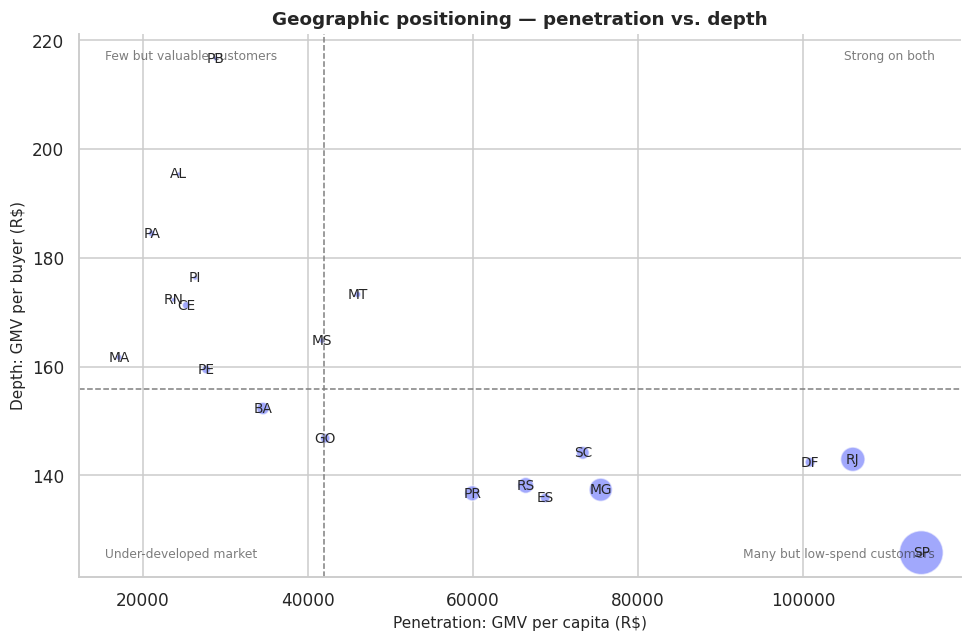

In [9]:
from olist_analytics.analyses.section2_geography import plot_penetration_vs_depth

fig = plot_penetration_vs_depth(state_table)
fig.show()


---
# 3. Seller performance & lifecycle

### 3.1 Quality & concentration

**📖 Definitions**

- **Pareto curve:** cumulative revenue % vs cumulative seller % (sorted highest-revenue first). Steep = concentrated supply (platform risk).
- **Quality floor (~4.0):** sellers below with meaningful volume → priority intervention list.


C:\Users\user\AppData\Local\Temp\ipykernel_12884\3160083138.py:7: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


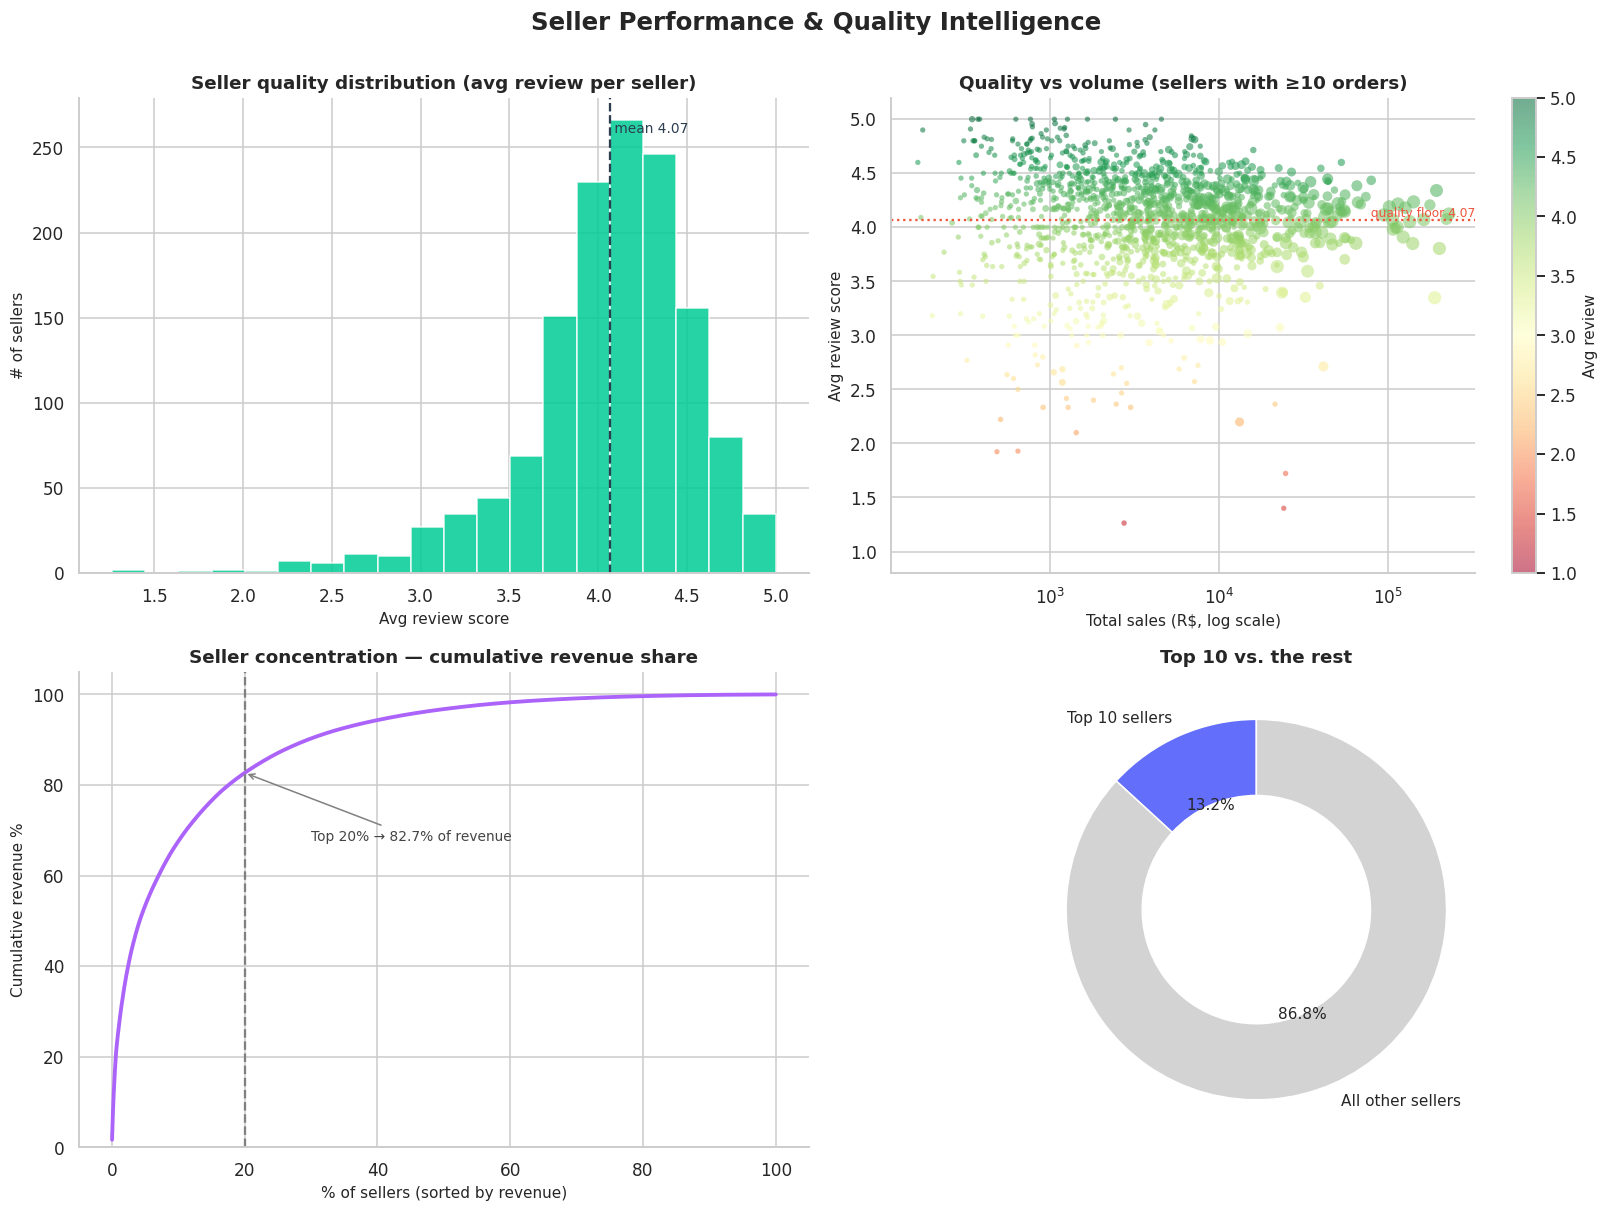

In [10]:
from olist_analytics.analyses.section3_sellers import (
    build_seller_stats, plot_seller_dashboard
)

seller_stats = build_seller_stats(data)
fig = plot_seller_dashboard(seller_stats, config)
fig.show()


### 3.2 Seller-cohort survival

Quarterly cohorts. Each row is sellers who joined in that quarter; cells beyond
the data window are masked. Replaces "active sellers per month" and "tenure
histogram" — both were collapsed views of the same information.


C:\Users\user\AppData\Local\Temp\ipykernel_12884\2971724369.py:7: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


Total sellers ever active: 2,970
Active in final 30 days:   1,295


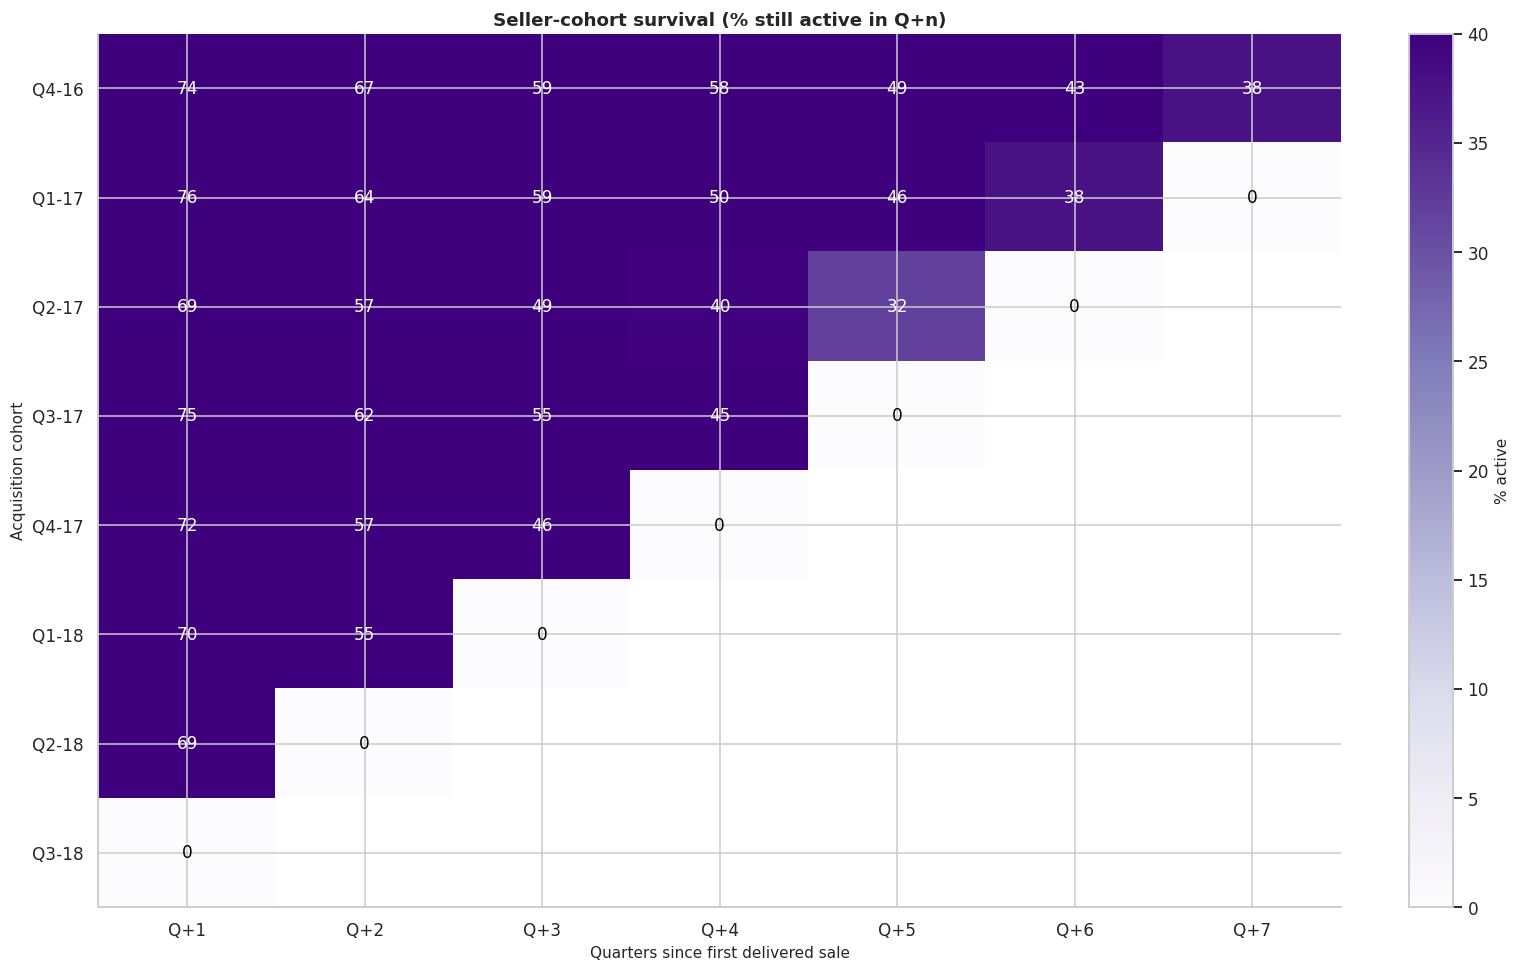

In [11]:
from olist_analytics.analyses.section3_sellers import (
    build_seller_cohort_survival, plot_cohort_heatmap, seller_scale_summary
)

survival = build_seller_cohort_survival(data, config)
fig = plot_cohort_heatmap(survival)
fig.show()

scale = seller_scale_summary(data)
print(f"Total sellers ever active: {scale['total_sellers']:,}")
print(f"Active in final 30 days:   {scale['active_final_30d']:,}")


---
# 4. Payment mix & non-completion drivers

### 4.1 Payment-type share of GMV

**📖 Boleto:** uniquely Brazilian — a printable bank slip paid at a bank or via
mobile banking. Order is placed *before* the slip is paid, so unpaid slips
become the leading source of cancellations.


C:\Users\user\AppData\Local\Temp\ipykernel_12884\2224231933.py:4: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


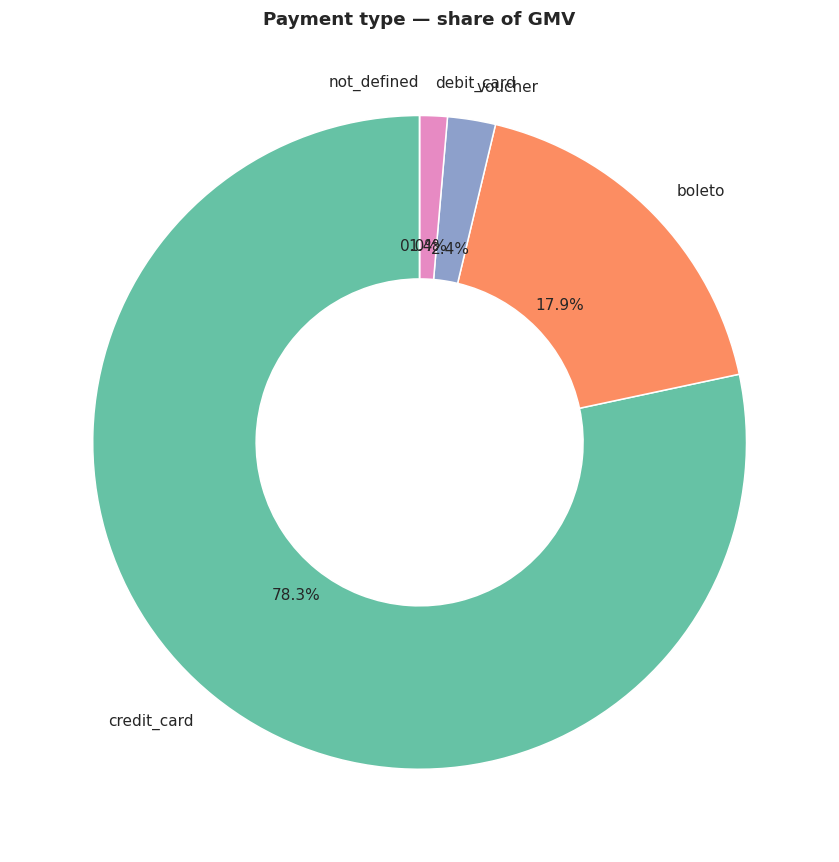

In [12]:
from olist_analytics.analyses.section4_payments import plot_payment_type_share

fig = plot_payment_type_share(data)
fig.show()


### 4.2 Credit-card installment buckets

Two side-by-side panels: % of credit-card orders and % of credit-card GMV per
bucket. The gap is the strategic story — if 10×+ installments are 7% of orders
but 18% of GMV, long installments unlock bigger baskets.


C:\Users\user\AppData\Local\Temp\ipykernel_12884\2037944738.py:7: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()



Avg ticket per bucket:
                  orders        gmv  avg_ticket
bucket                                         
1× (single)        25407  2440445.0        96.0
2–3× (short)       22824  3070575.0       134.0
4–9× (long)        22731  4697290.0       206.0
10×+ (very long)    5656  2333773.0       412.0


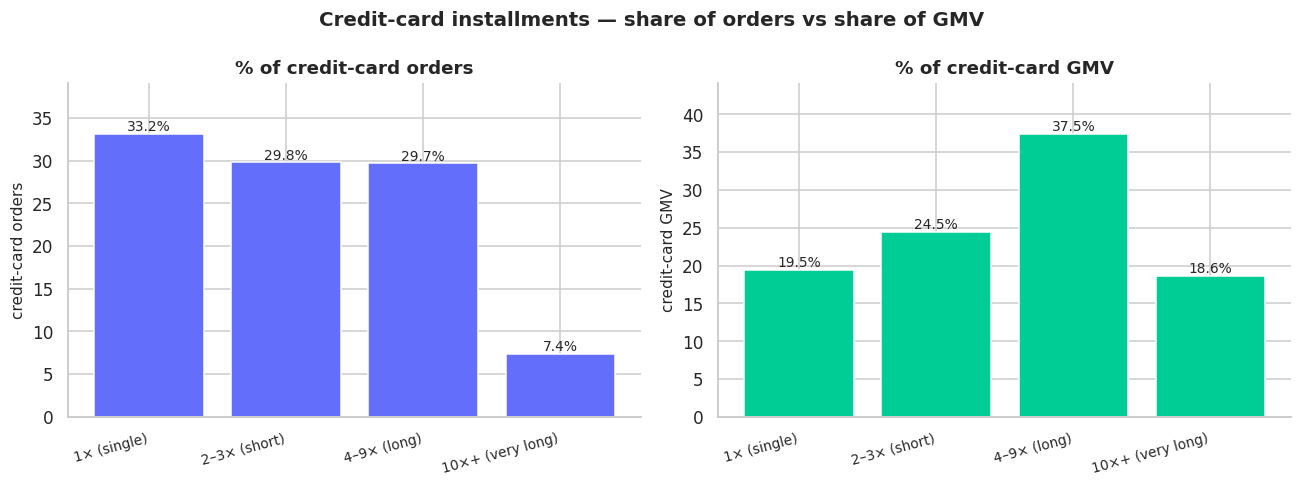

In [13]:
from olist_analytics.analyses.section4_payments import (
    installment_summary, plot_installments
)

inst = installment_summary(data)
fig = plot_installments(inst)
fig.show()

print("\nAvg ticket per bucket:")
print(inst[["orders", "gmv", "avg_ticket"]].round(0))


### 4.3 Non-completion by payment type

Two distinct levers:

- **Boleto pre-approval cancellations** = unpaid slips. *Conversion problem* — shorten the slip-expiration window or push reminders.
- **Credit-card post-approval cancellations** = seller-side fulfillment failure or fraud flags. *Operations problem.*


C:\Users\user\AppData\Local\Temp\ipykernel_12884\469290100.py:7: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()



Platform-wide non-completion rate: 1.24%

Per-payment-type breakdown:
              orders  incomplete  rate
payment_type                          
debit_card      1527          13  0.85
credit_card    74975         859  1.15
boleto         19784         245  1.24
voucher         3151         114  3.62


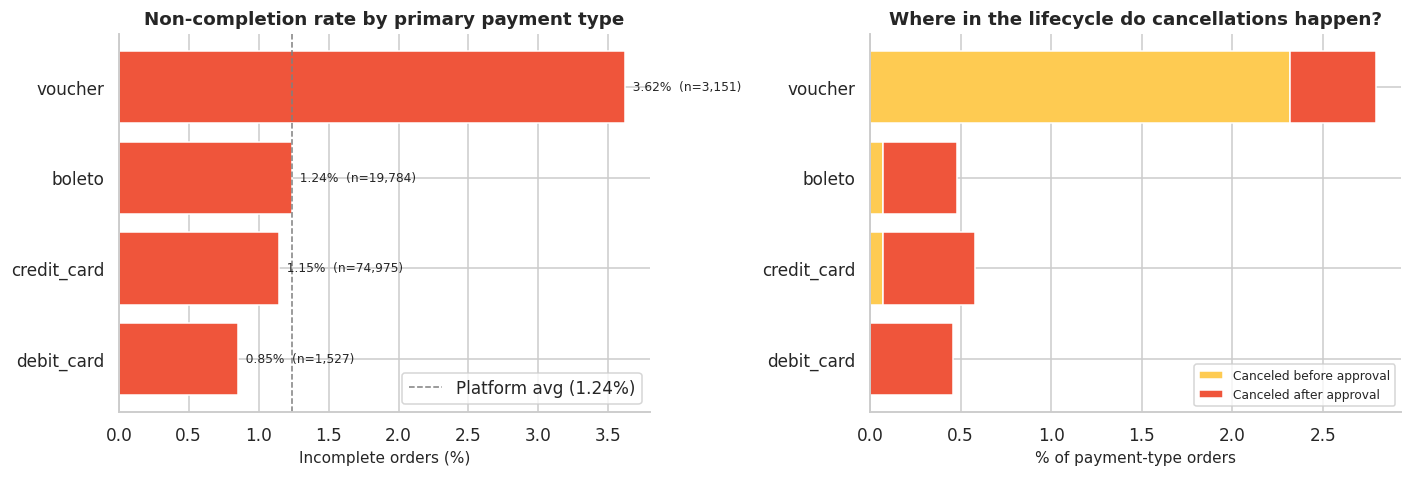

In [14]:
from olist_analytics.analyses.section4_payments import (
    build_payment_completion_table, plot_payment_completion
)

pay_stats, stage_split, platform_avg = build_payment_completion_table(data, config)
fig = plot_payment_completion(pay_stats, stage_split, platform_avg)
fig.show()

print(f"\nPlatform-wide non-completion rate: {platform_avg:.2f}%")
print("\nPer-payment-type breakdown:")
print(pay_stats.round(2))


---
# 5. Product categories & customer experience

### 5.1 Revenue share by product group

Computed on **delivered orders only** and excludes freight. The category
taxonomy collapses Olist's 70-odd raw labels into 7 broad groups — see
`olist_analytics/transforms/categories.py` for the mapping.


C:\Users\user\AppData\Local\Temp\ipykernel_12884\3619008280.py:7: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


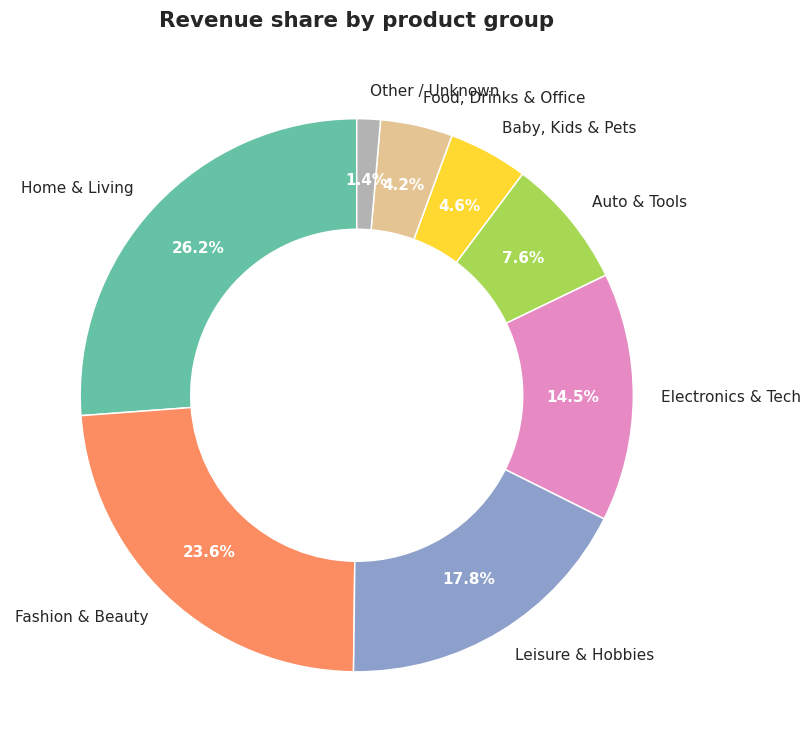

In [15]:
from olist_analytics.analyses.section5_categories import (
    revenue_by_group, plot_revenue_pie
)

rev = revenue_by_group(data)
fig = plot_revenue_pie(rev)
fig.show()


### 5.2 Same-category returning customers

Top groups ranked by % of buyers who bought in the **same** group again.
Platform-wide rate is low (consistent with a low-frequency marketplace) but
relative gaps across groups are large and decision-relevant.

Home & Living's lead reflects both genuine within-group adjacency *and* the
breadth of the group itself (furniture, housewares, decor, appliances).
Smaller, narrower groups face a structural ceiling. Treat as a directional
ranking, not a precise effect size.


C:\Users\user\AppData\Local\Temp\ipykernel_12884\1042564976.py:7: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()



Platform-wide same-category repeat rate: 1.83%

Top groups by repeat rate:
                       buyers  repeat_buyers  repeat_rate
group                                                    
Home & Living           26807            754         2.81
Fashion & Beauty        20167            368         1.82
Leisure & Hobbies       16648            264         1.59
Electronics & Tech      15247            208         1.36
Baby, Kids & Pets        4473             46         1.03
Auto & Tools             5874             55         0.94
Food, Drinks & Office    4430             38         0.86
Other / Unknown          1444              6         0.42


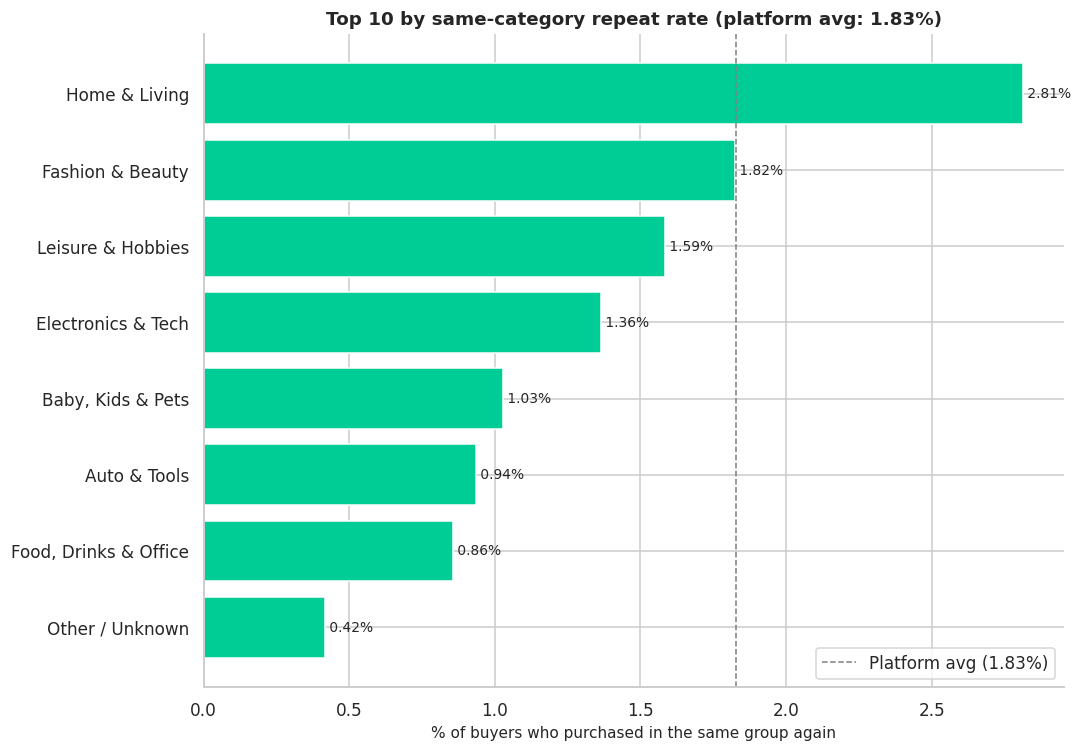

In [16]:
from olist_analytics.analyses.section5_categories import (
    same_category_repeat_table, plot_repeat_rate
)

repeat_table, overall = same_category_repeat_table(data, config)
fig = plot_repeat_rate(repeat_table, overall)
fig.show()

print(f"\nPlatform-wide same-category repeat rate: {overall:.2f}%")
print("\nTop groups by repeat rate:")
print(repeat_table.nlargest(10, "repeat_rate").round(2))


### 5.3 Drivers of negative reviews

Keyword-based topic extraction over Portuguese review comments scored 1–2★.
Each bar = % of negative reviews that mention each topic. Useful for
prioritizing CX interventions: delivery-related complaints typically dominate,
which means logistics is the biggest single lever on review score.


c:\Users\user\Downloads\repo\olist_analytics\analyses\section5_categories.py:181: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches = msgs.str.contains(pattern, regex=True, na=False)
C:\Users\user\AppData\Local\Temp\ipykernel_12884\2170290030.py:7: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


                       Topic_PT                       Topic_EN  Count  Pct
     Atraso na entrega / Demora                 Delivery delay   1933 13.3
      Qualidade ruim do produto           Poor product quality    873  6.0
      Produto errado ou trocado       Wrong or swapped product    743  5.1
     Faltando peça / Incompleto     Missing parts / Incomplete    711  4.9
Atendimento ruim / Sem resposta          Poor customer service    686  4.7
        Problemas com reembolso                  Refund issues    624  4.3
     Não recebeu / Nunca chegou Didn't receive / Never arrived    531  3.6
    Veio quebrado / com defeito     Broken / Defective product    526  3.6


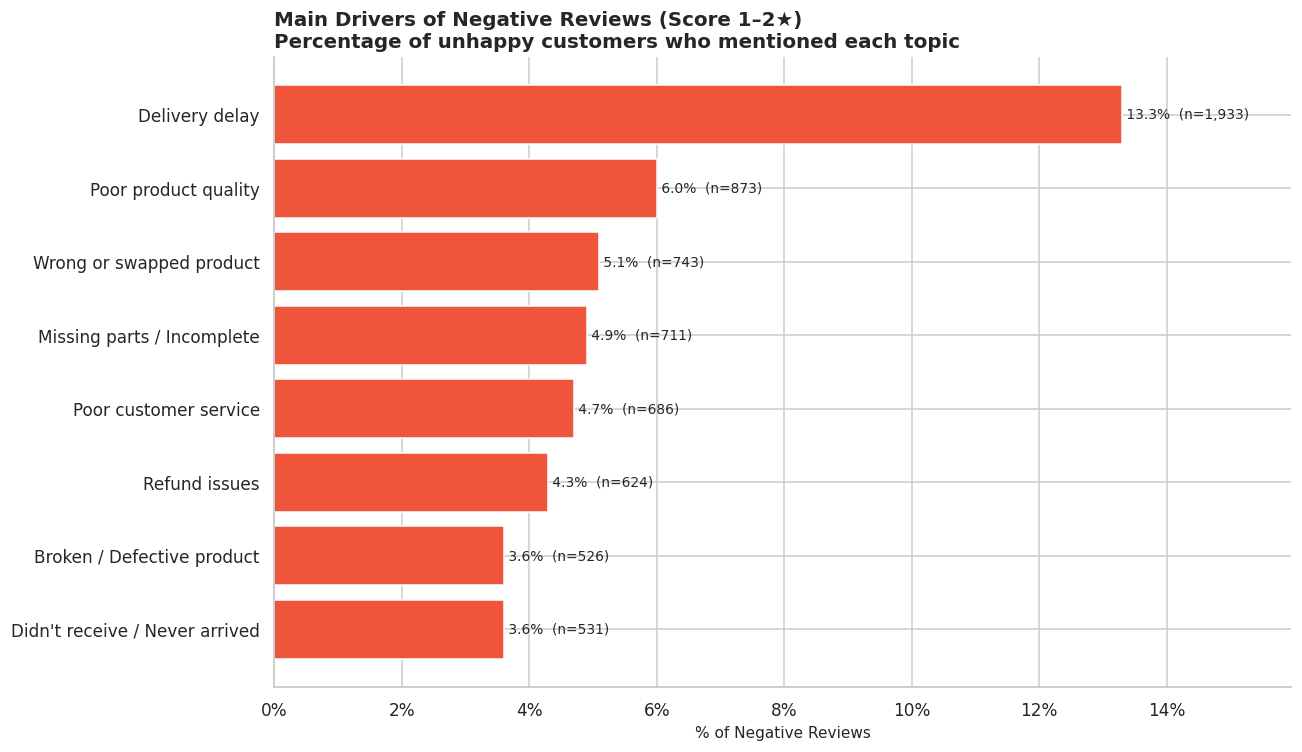

In [17]:
from olist_analytics.analyses.section5_categories import (
    negative_review_topics, plot_negative_review_topics
)

topics = negative_review_topics(data)
fig = plot_negative_review_topics(topics)
fig.show()

print(topics.sort_values("Pct", ascending=False).to_string(index=False))


---
## Summary — the five questions answered

| Section | Question | Top finding |
|---|---|---|
| 1. Overview | How big and how healthy? | ~99k orders, ~3% repeat rate (structural to low-frequency category mix) |
| 2. Geography | Where to invest? | SP dominates raw volume; per-capita view reshuffles the priority list |
| 3. Sellers | Is supply healthy? | Heavy concentration — top 20% of sellers capture ~80% of GMV |
| 4. Payments | Where do orders fail? | Boleto pre-approval cancellations are the primary lever |
| 5. Categories | What sells, what hurts CX? | Home & Living leads revenue and same-cat repeat; logistics drives negative reviews |
